In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
# format="mixed" parses each value independently (the column mixes dd/mm/yyyy and
# dd/mm/yy, e.g. some days in Oct-Dec 2024 use a 2-digit year); inferring a single
# format for the whole column would silently coerce mismatched rows to NaT and drop
# them in the groupby below.
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], format="mixed", dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()

## Decantation Basin

In [4]:
# select column that have BC in their name
DE_data = avgdata[['DATE'] + [col for col in avgdata.columns if 'DE' in col]]
DE_data.head()

,DATE,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,Turbidité_O_DE_A,Ph_O_DE_B,Température_O_DE_B,Conductivité_O_DE_B,TDS_O_DE_B,Turbidité_O_DE_B
0,2024-01-01,8.210000,16.966667,55.033333,33.02,0.116667,8.210000,16.933333,55.033333,23.02,0.140000
1,2024-01-02,8.200000,16.533333,55.000000,33.00,0.350000,8.200000,16.433333,55.000000,33.00,0.273333
2,2024-01-03,8.163333,17.500000,54.833333,32.90,0.213333,8.186667,17.466667,54.833333,32.90,0.180000
3,2024-01-04,8.186667,16.500000,55.066667,33.04,0.276667,8.183333,16.500000,55.066667,33.04,0.190000
4,2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Descriptive Statistics

In [5]:
DE_data.describe()

,DATE,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,Turbidité_O_DE_A,Ph_O_DE_B,Température_O_DE_B,Conductivité_O_DE_B,TDS_O_DE_B,Turbidité_O_DE_B
count,346,307.000000,307.000000,33.000000,32.000000,306.000000,309.000000,310.000000,32.000000,32.000000,309.000000
mean,2024-07-06 00:00:00,8.064517,20.128534,54.954040,32.988438,0.966917,8.067071,20.087269,54.942187,32.652812,0.933223
min,2024-01-01 00:00:00,7.880000,15.233333,53.700000,32.220000,0.010000,7.890000,15.233333,52.400000,23.020000,0.010000
25%,2024-03-29 06:00:00,8.010000,17.000000,54.933333,32.960000,0.445000,8.010000,17.037500,54.933333,32.955000,0.410000
50%,2024-06-29 12:00:00,8.063333,20.100000,55.033333,33.030000,0.750000,8.063333,20.075000,55.050000,33.030000,0.680000
75%,2024-09-29 18:00:00,8.105000,22.900000,55.133333,33.090000,1.142500,8.103333,22.900000,55.141667,33.085000,1.060000
max,2025-01-31 00:00:00,8.300000,28.000000,55.466667,33.280000,10.233333,8.900000,28.000000,55.466667,33.280000,9.343333
std,NaN,0.071057,3.172274,0.369004,0.204610,0.954222,0.084137,3.162656,0.526366,1.785906,0.986429


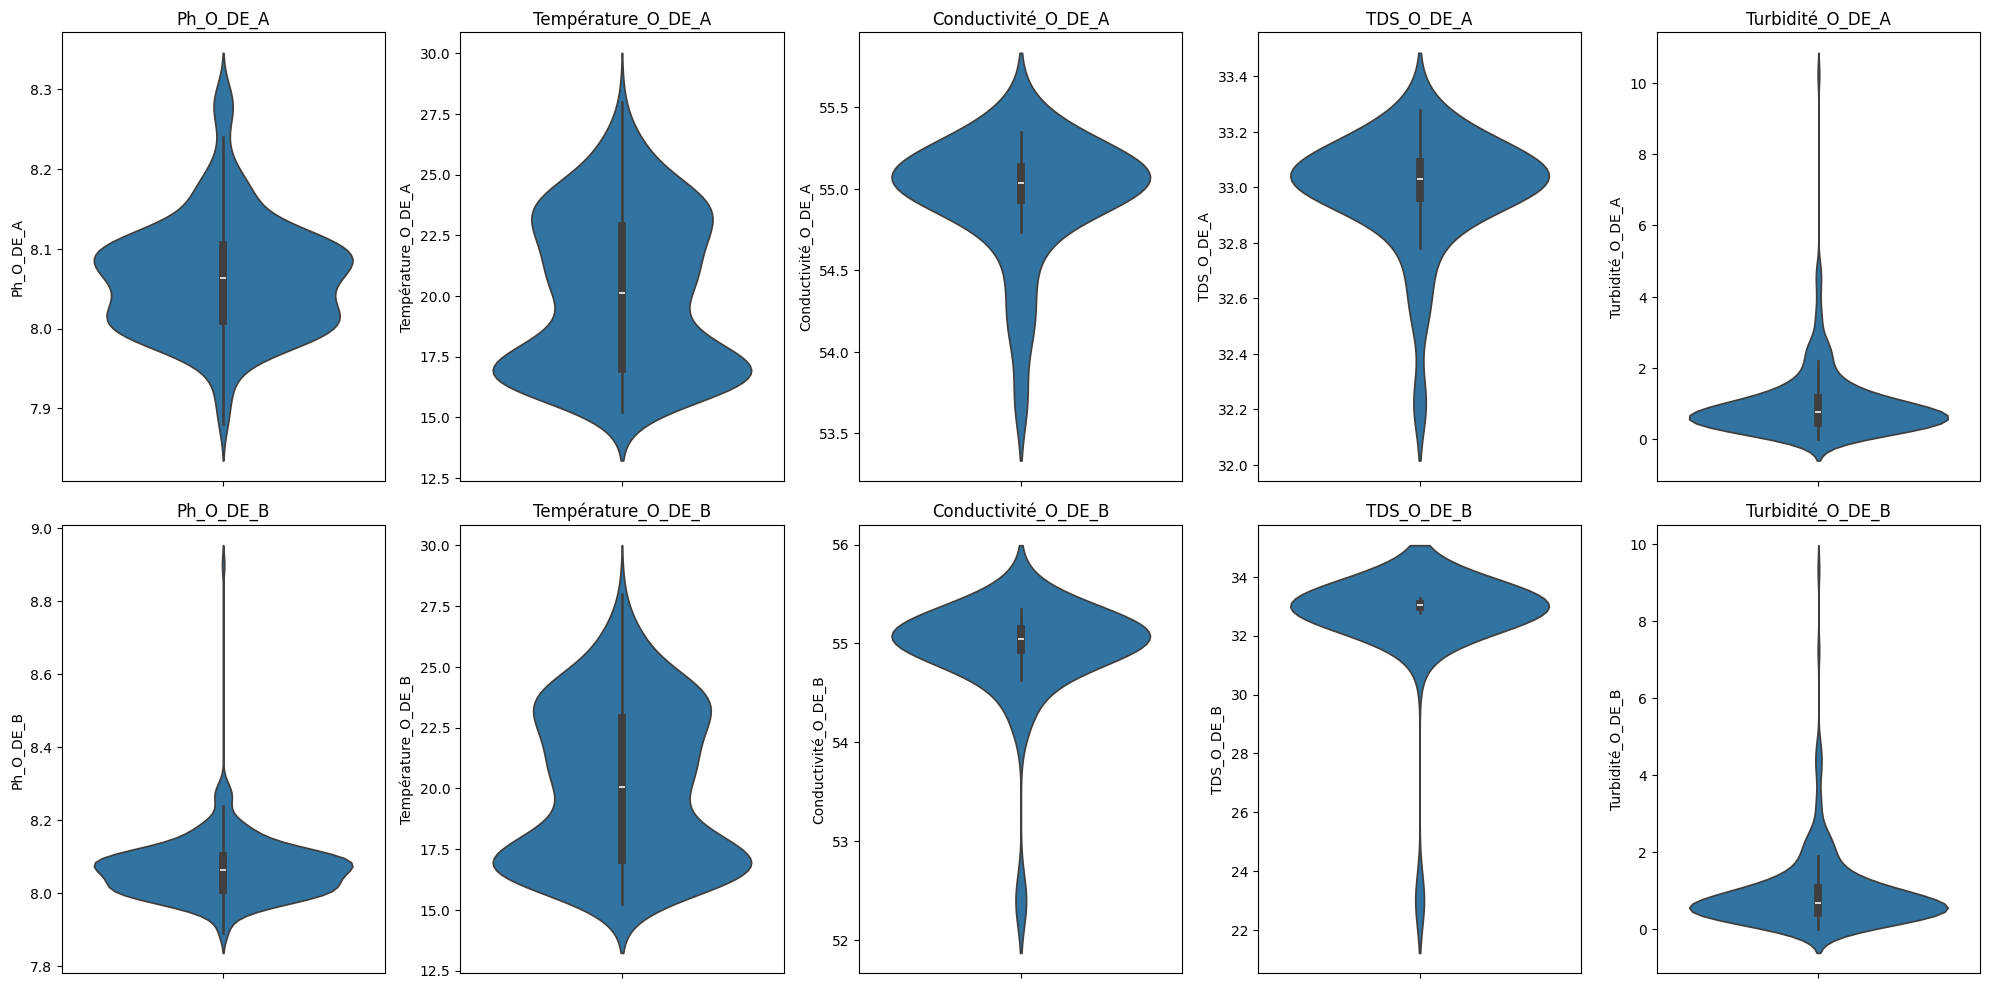

In [10]:
# boxplot of DE data
n_cols = 5
n_rows = -(-((len(DE_data.columns) - 1)) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, DE_data.columns[1:]):
    sns.violinplot(y=DE_data[col], ax=ax)
    ax.set_title(col)
for ax in axes[len(DE_data.columns) - 1:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Temporal Evolution of the data

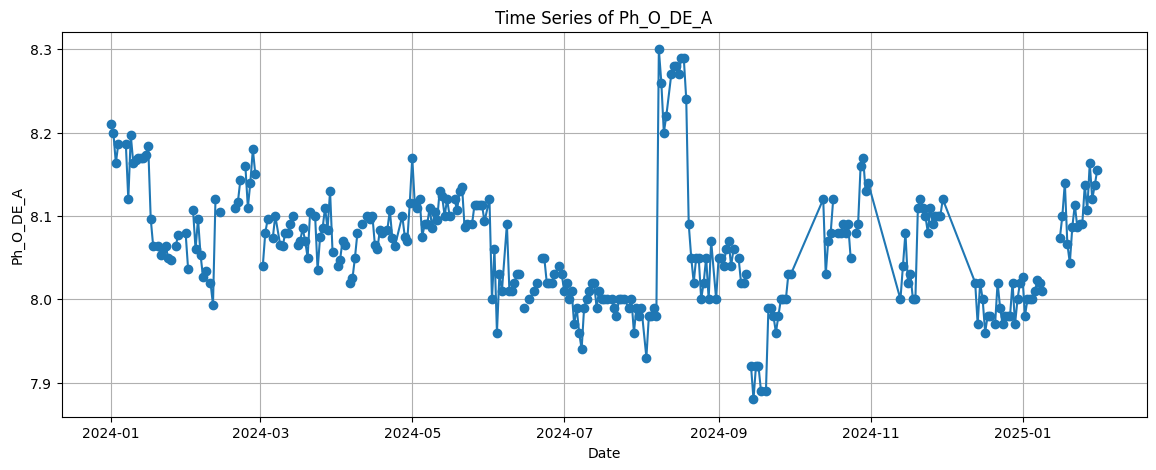

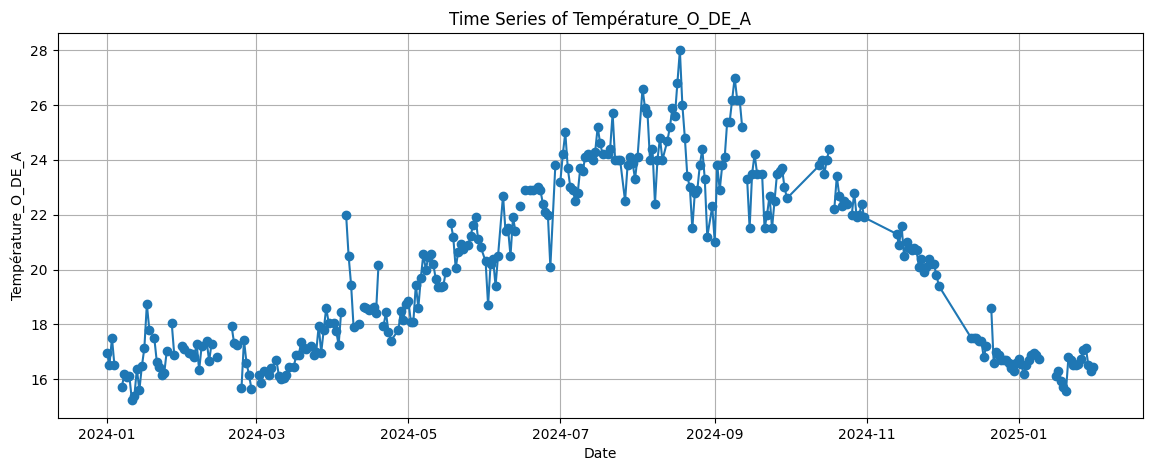

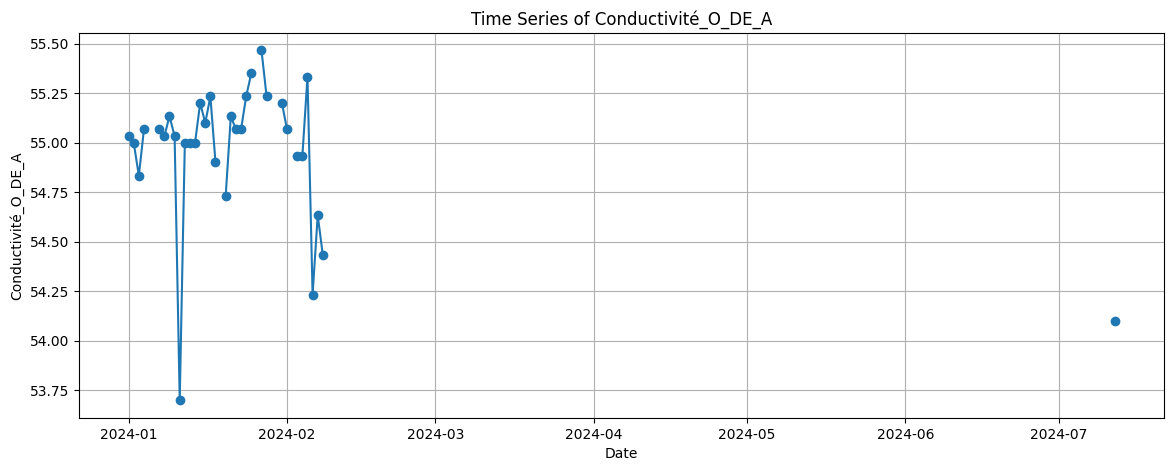

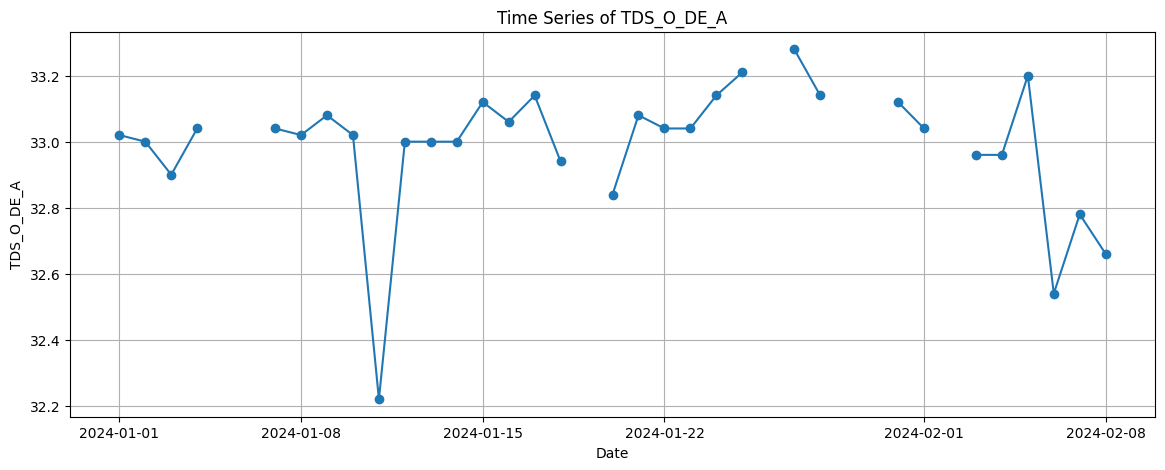

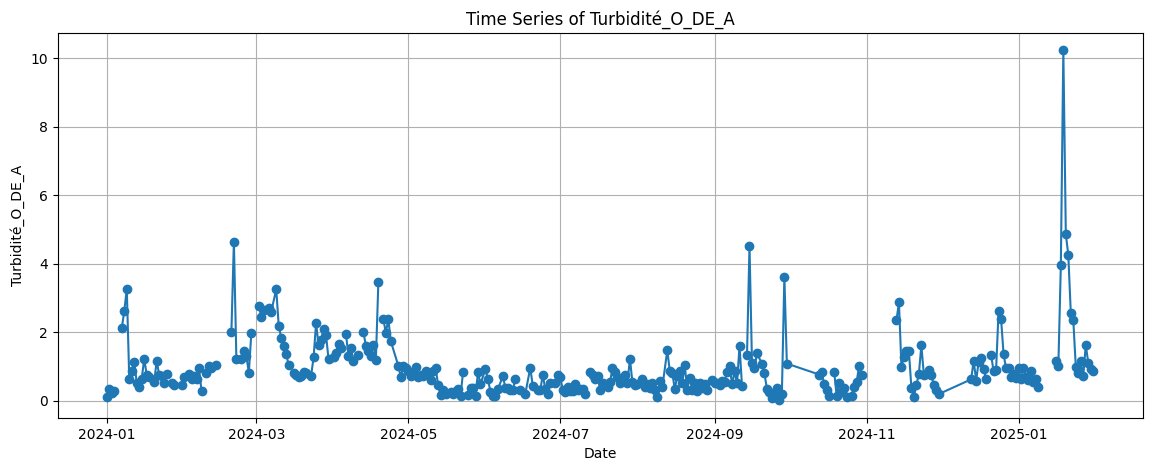

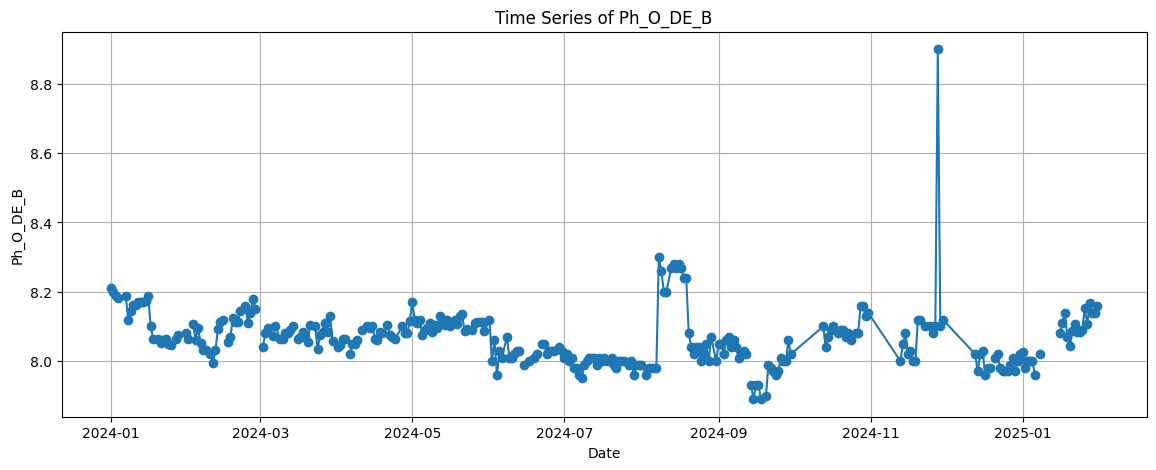

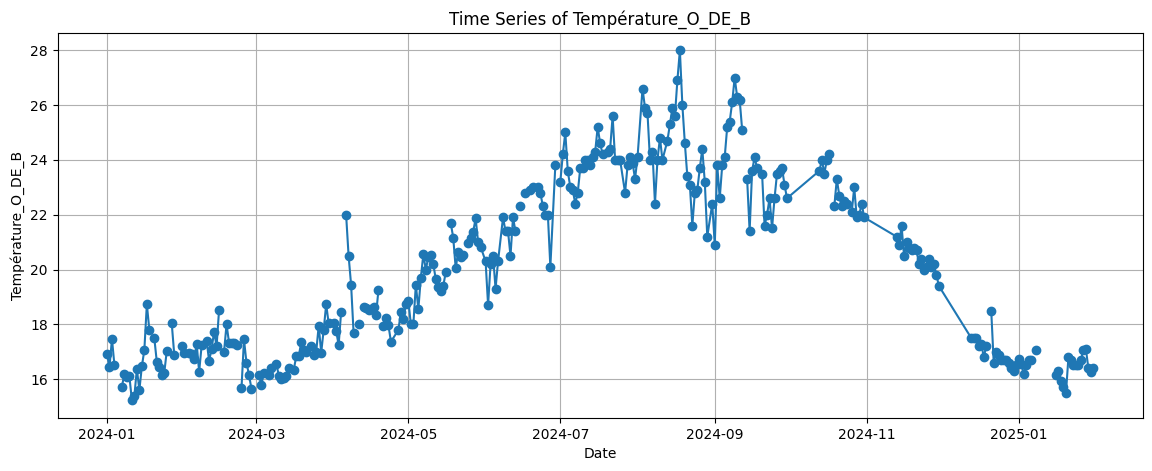

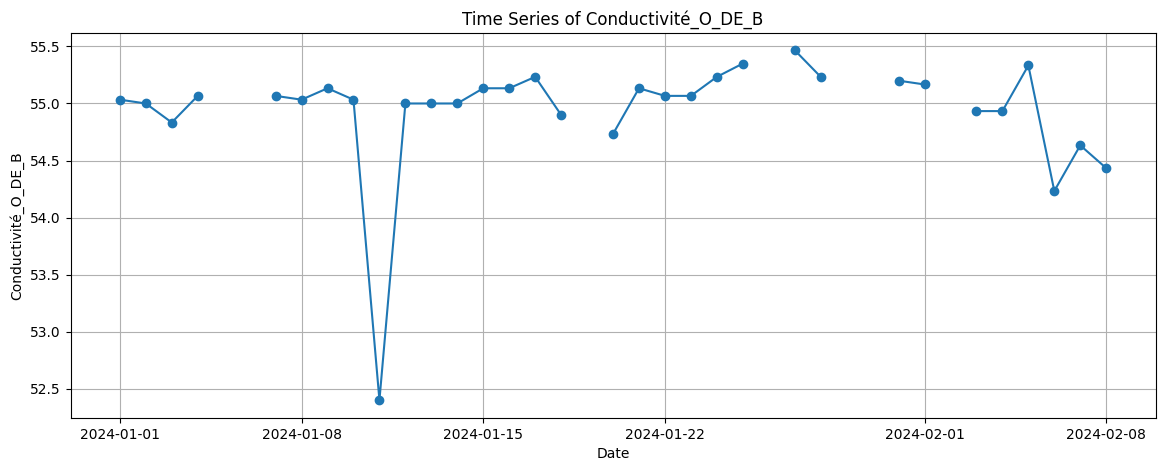

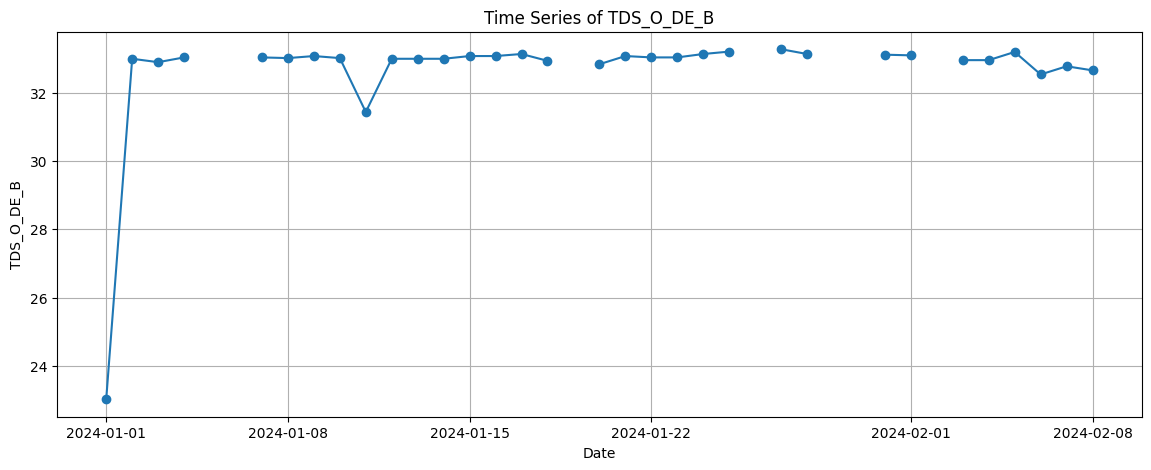

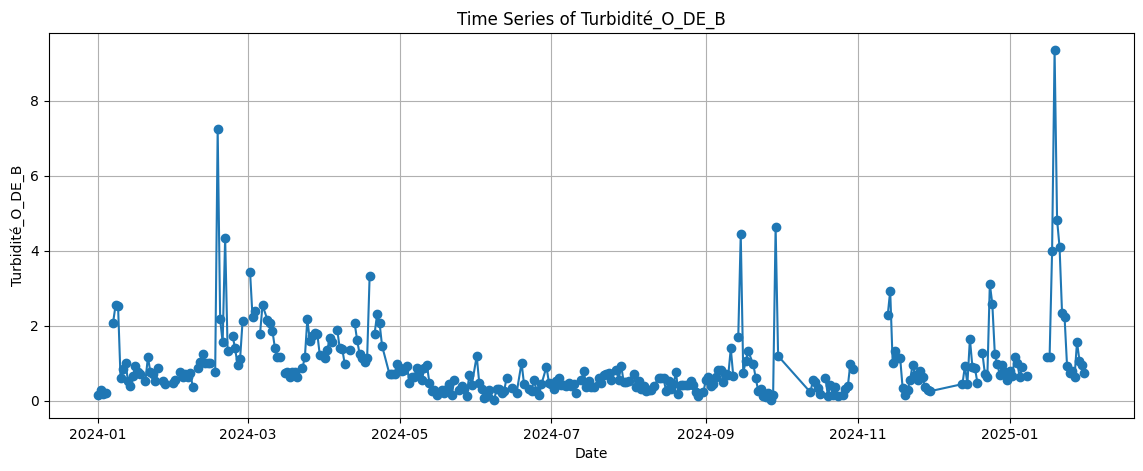

In [11]:
for col in DE_data.columns:
    if col != 'DATE':
        plt.figure(figsize=(14, 5))
        plt.plot(DE_data['DATE'], DE_data[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()

#### Visualtion of the relationship between variables

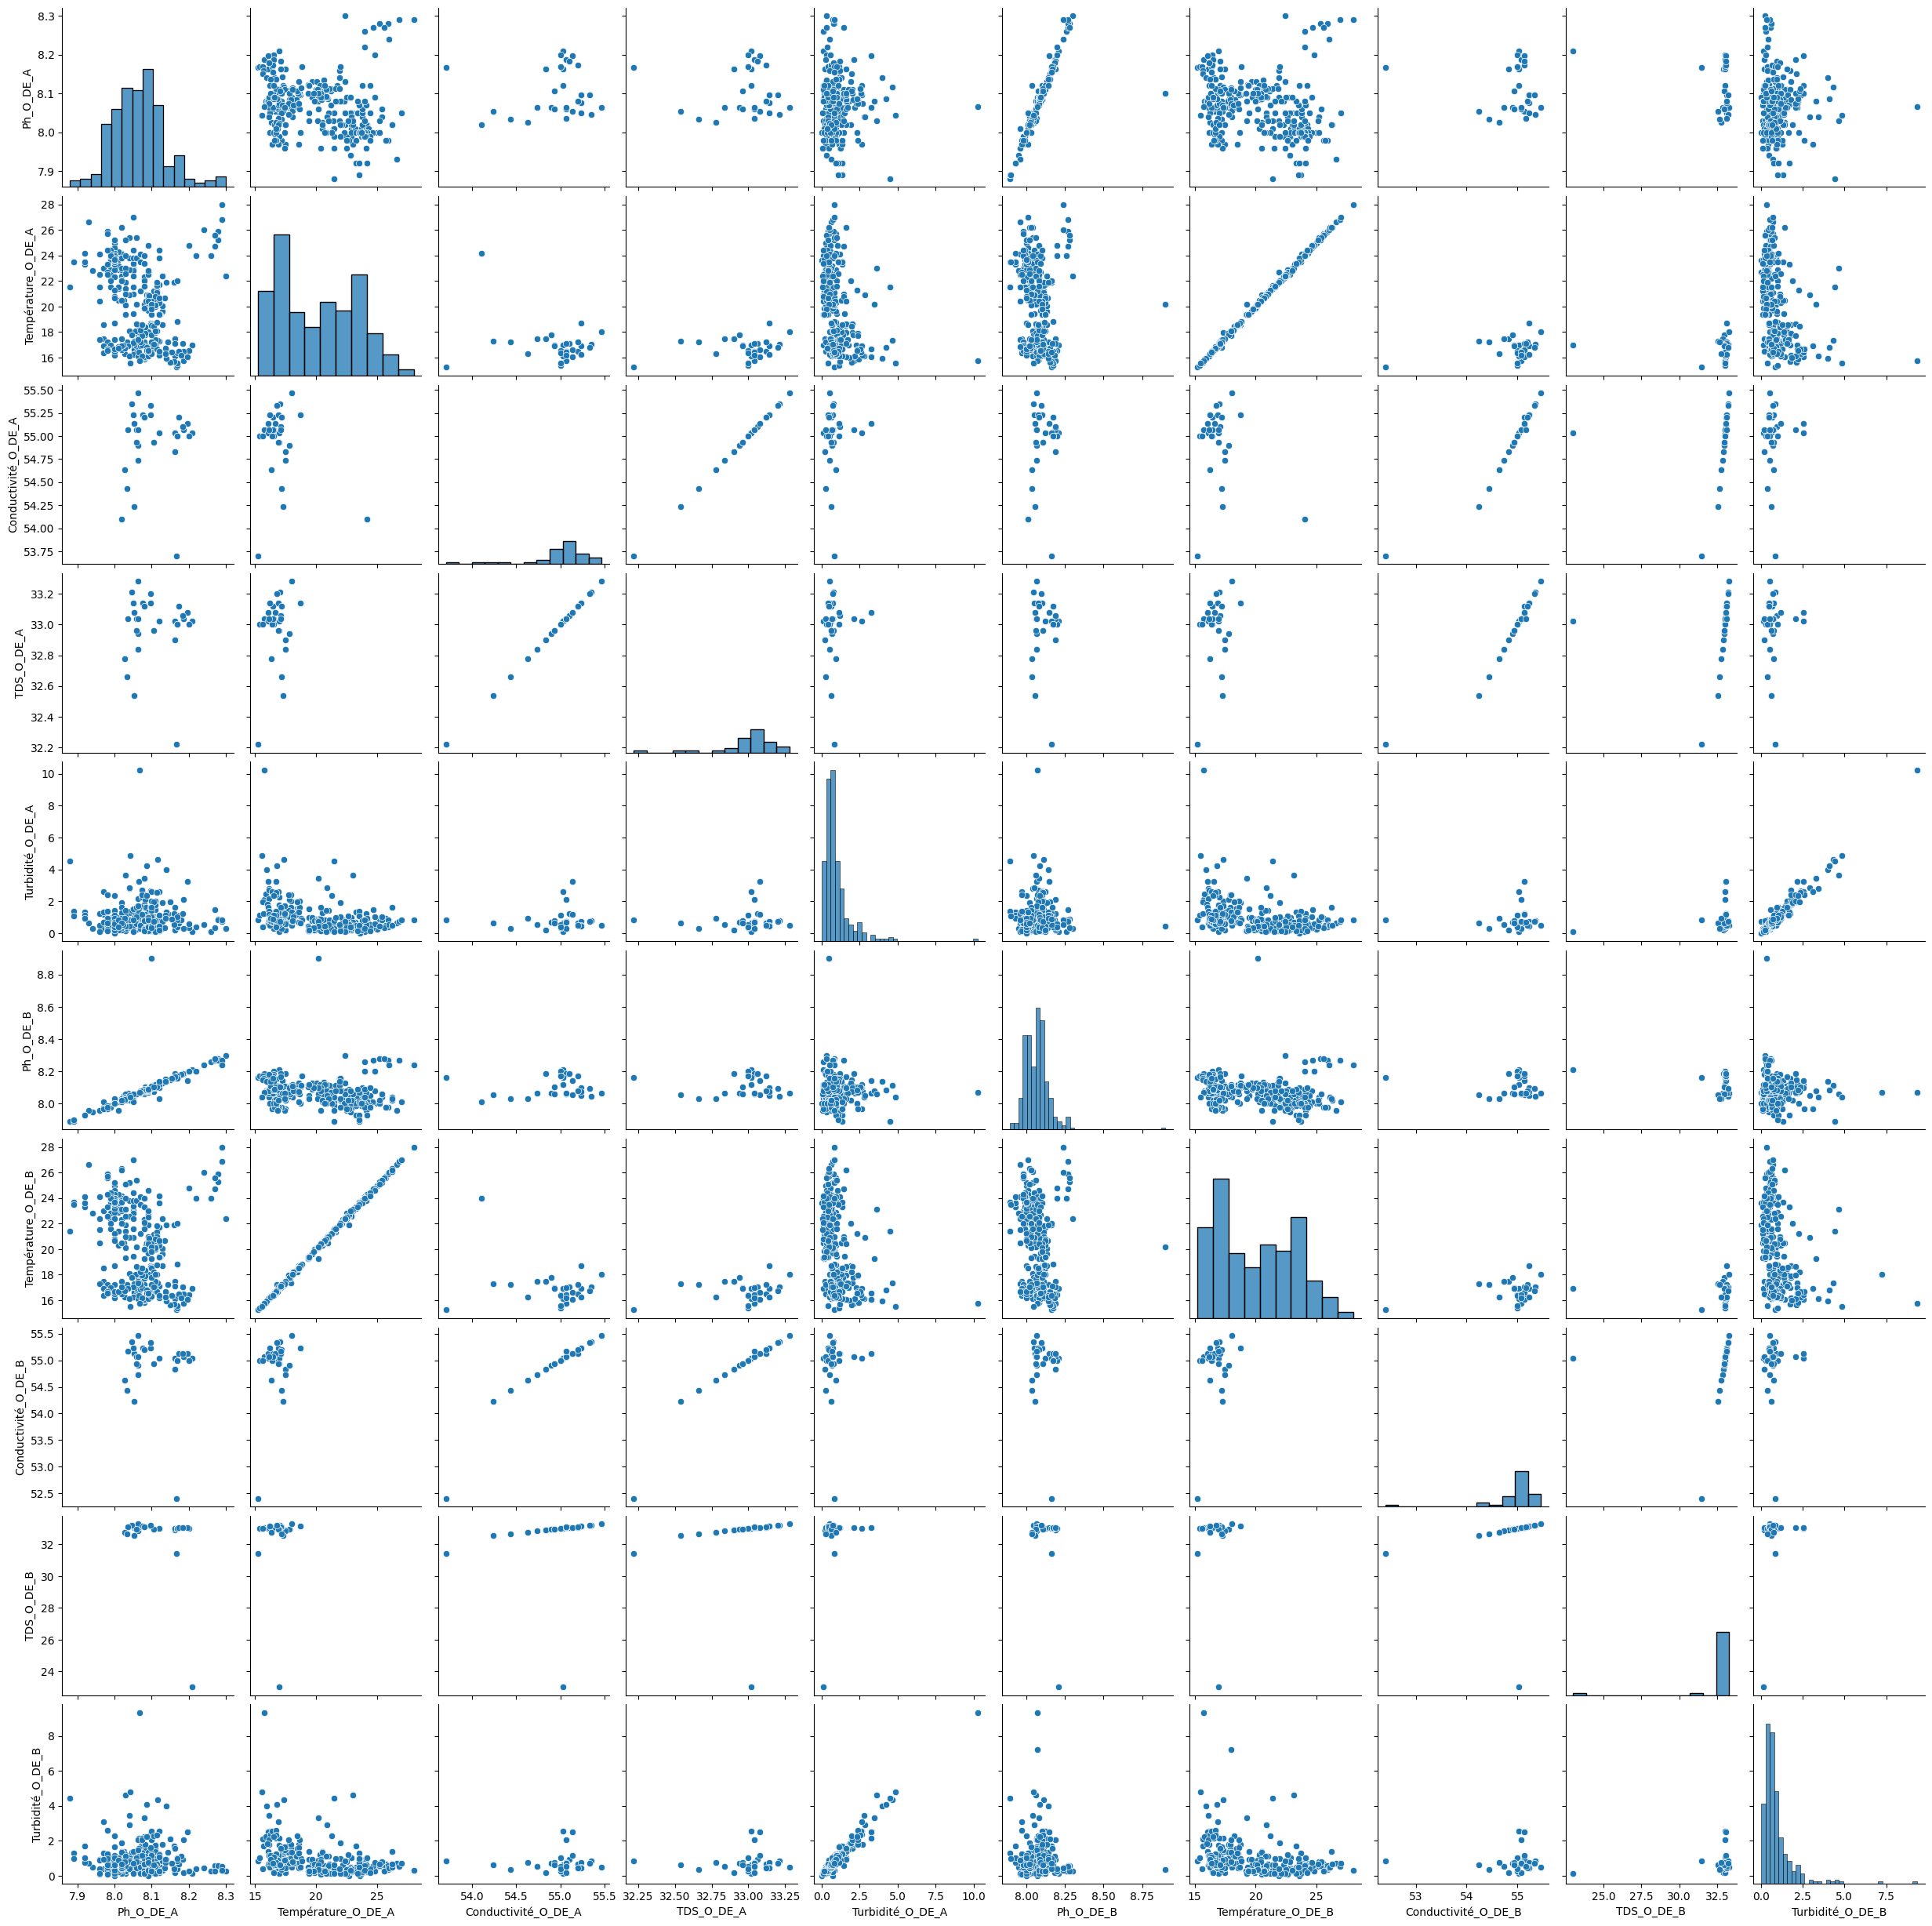

In [12]:
sns.pairplot(DE_data.iloc[:, 1:])

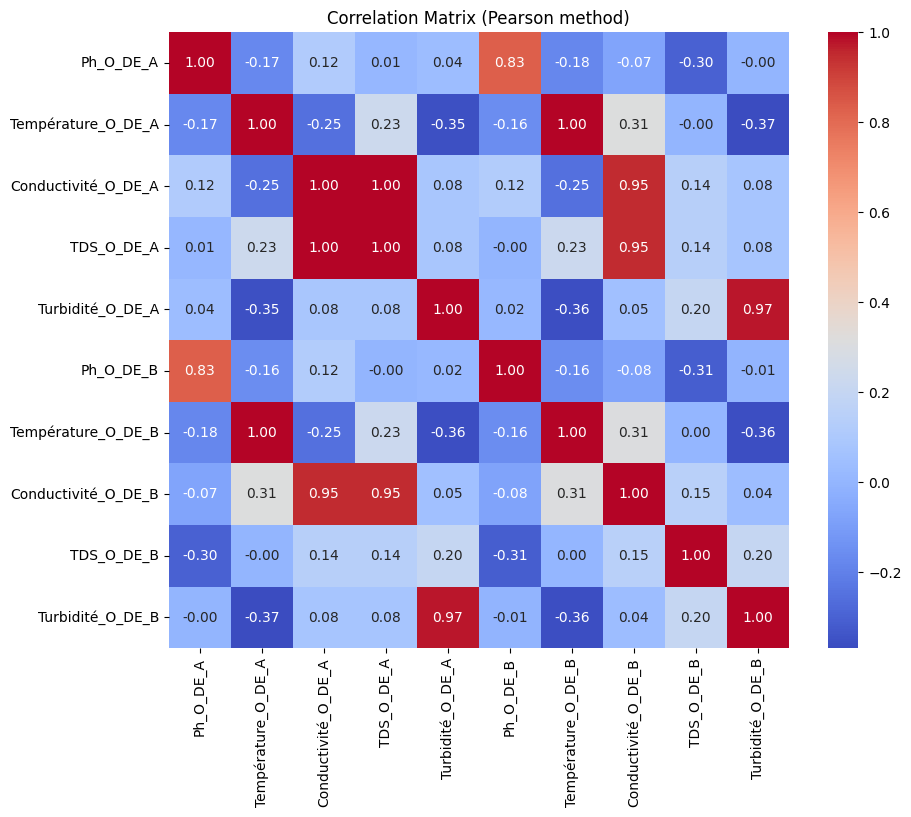

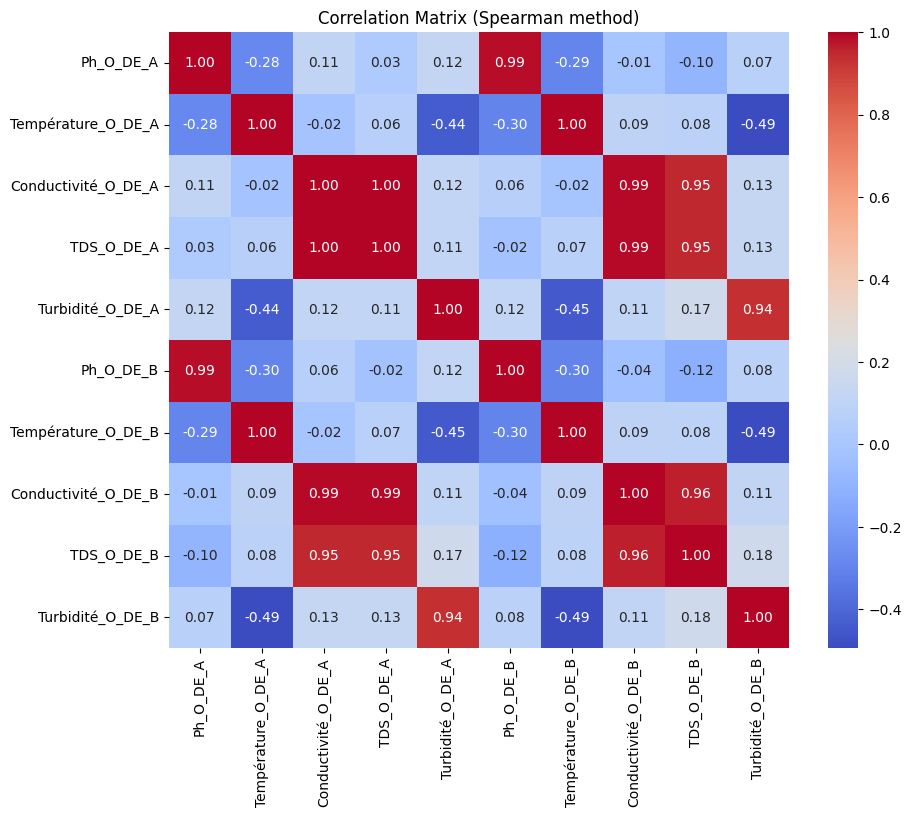

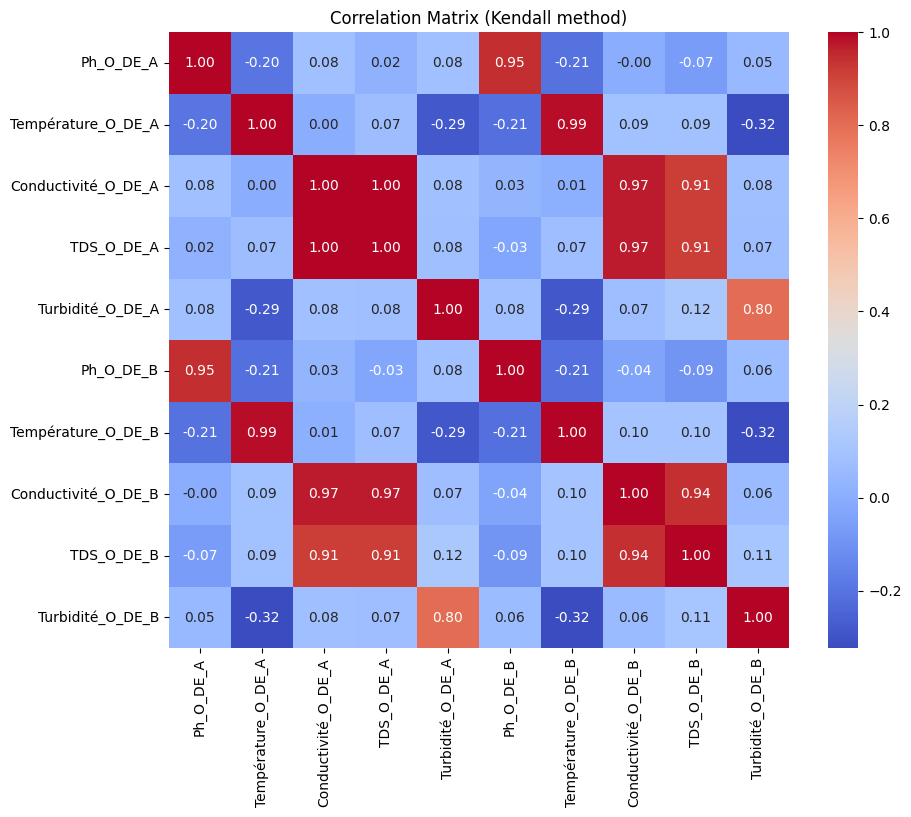

In [13]:
# calculate the correlation matrix using Pearson correlation, spearman correlation, and Kendall correlation
correlation_methods = ['pearson', 'spearman', 'kendall']
for method in correlation_methods:
    corr_matrix = DE_data.iloc[:, 1:].corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix ({method.capitalize()} method)')
    plt.show()

#### Time series features analysis

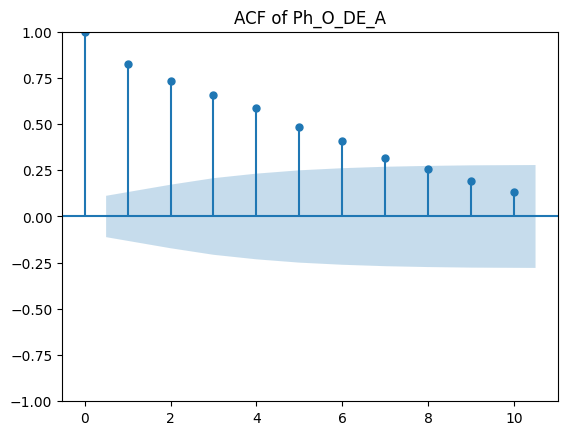

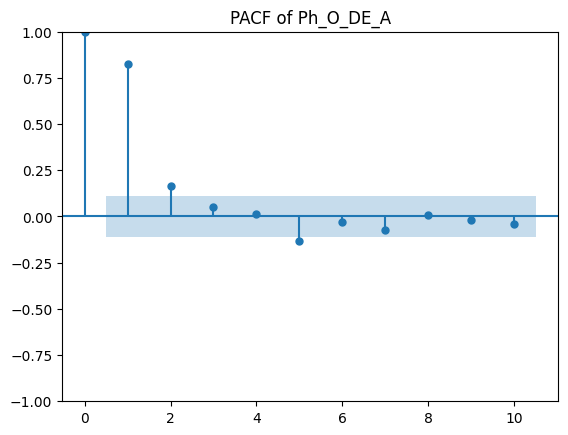

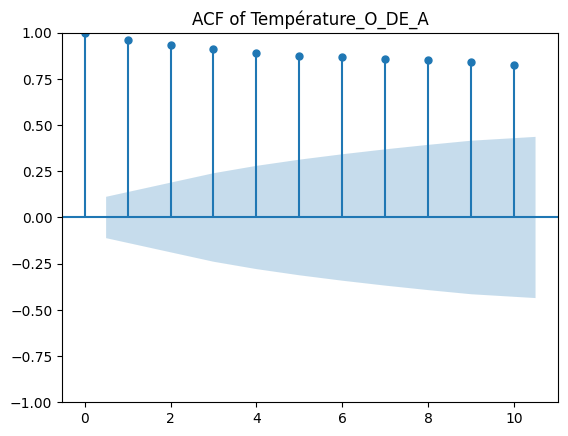

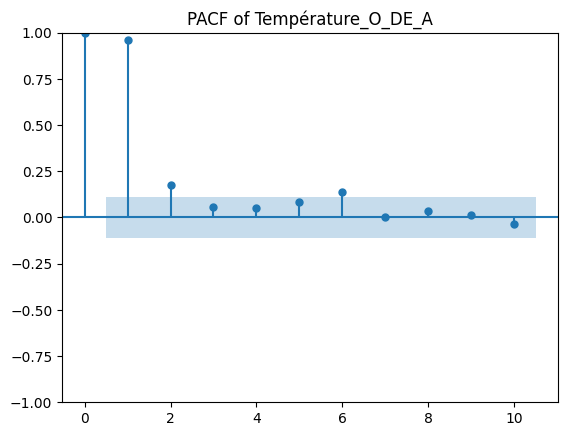

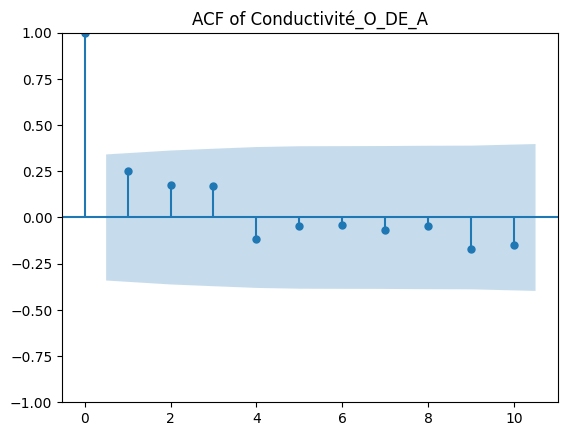

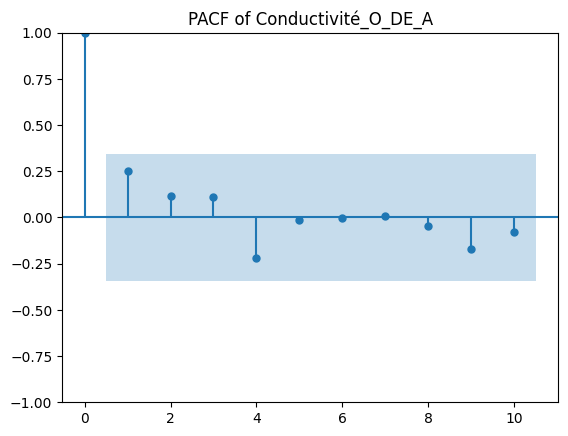

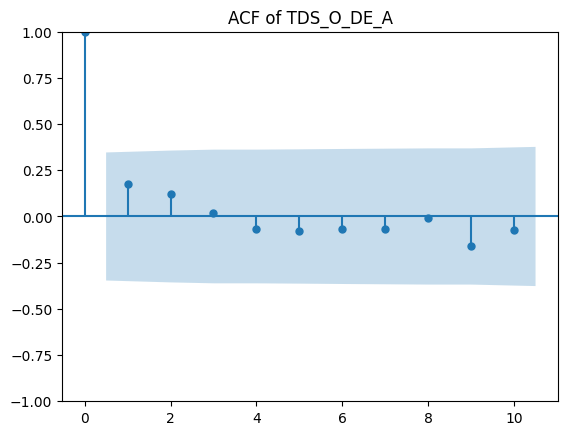

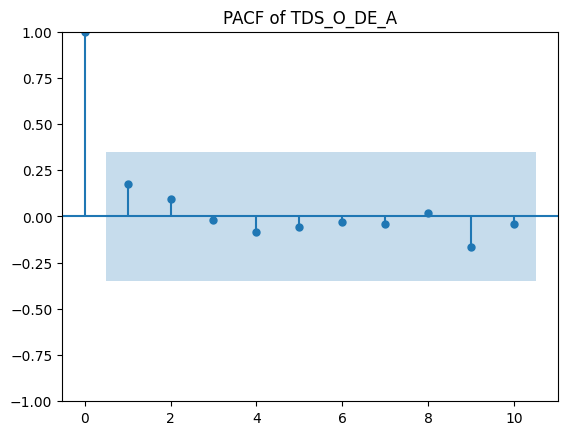

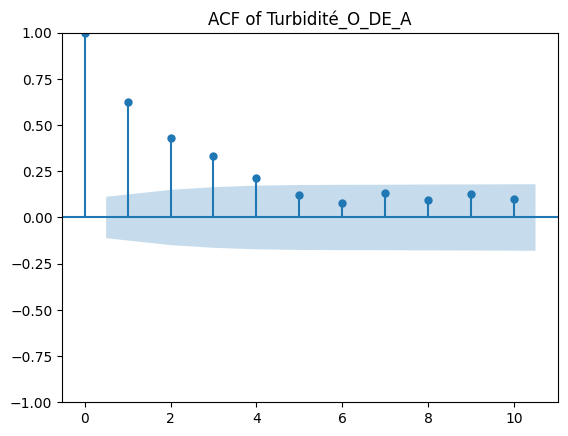

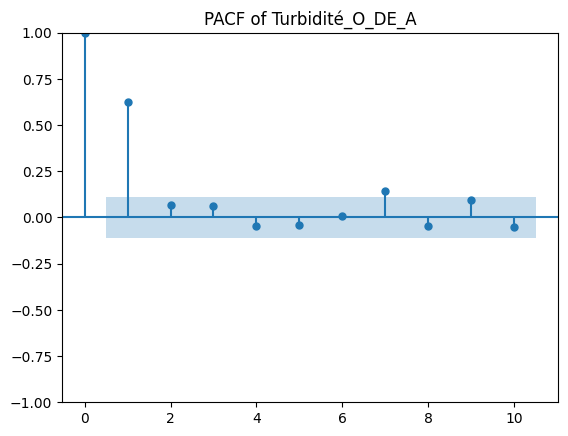

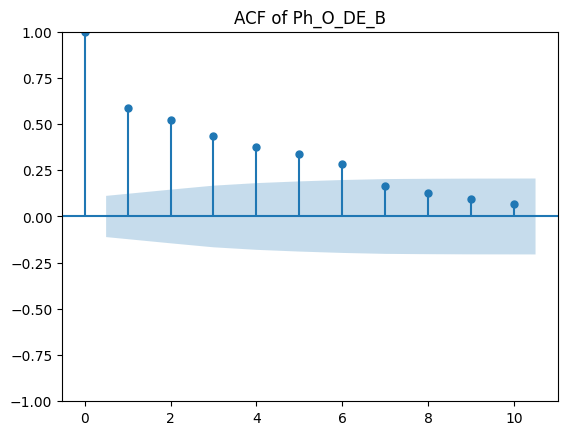

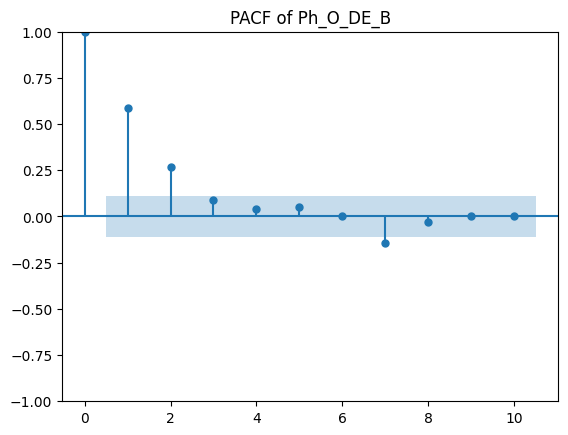

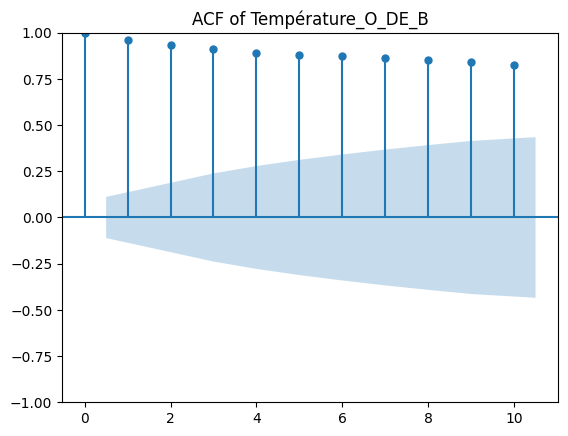

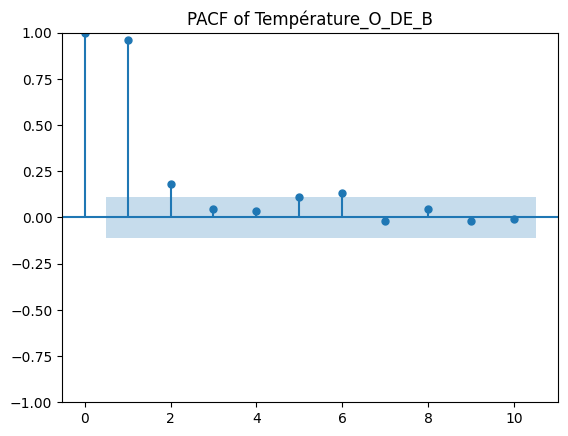

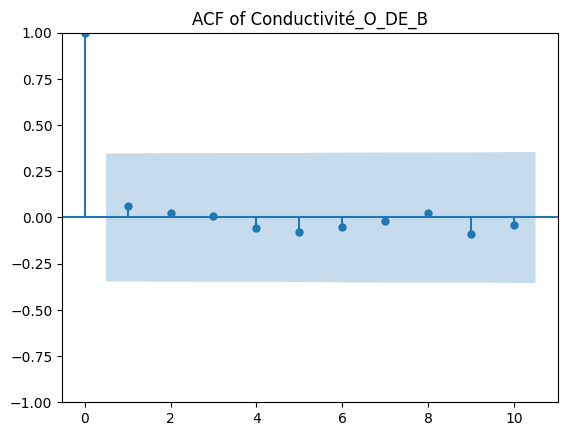

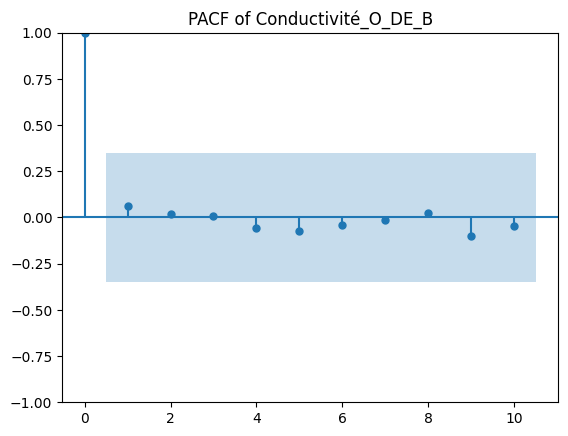

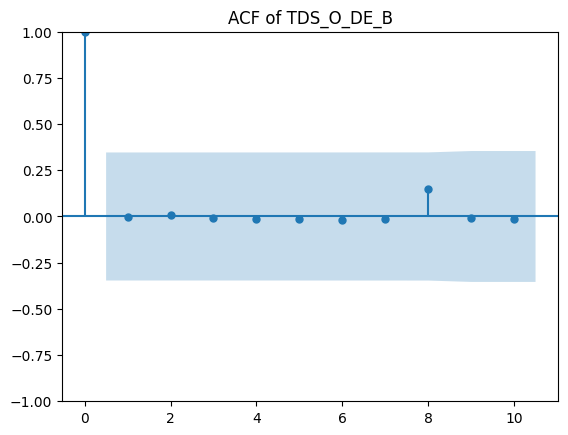

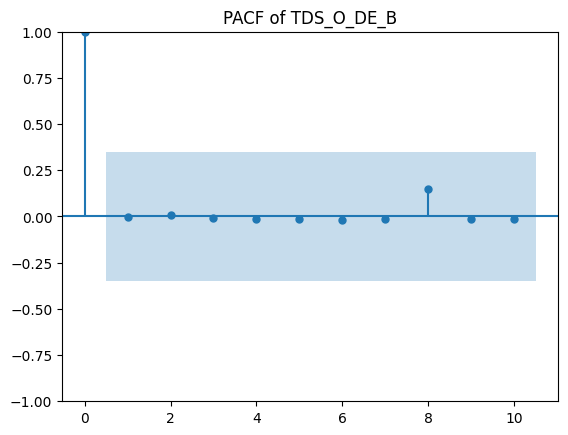

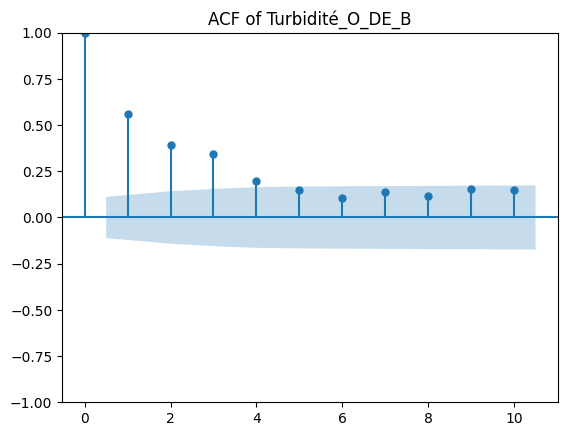

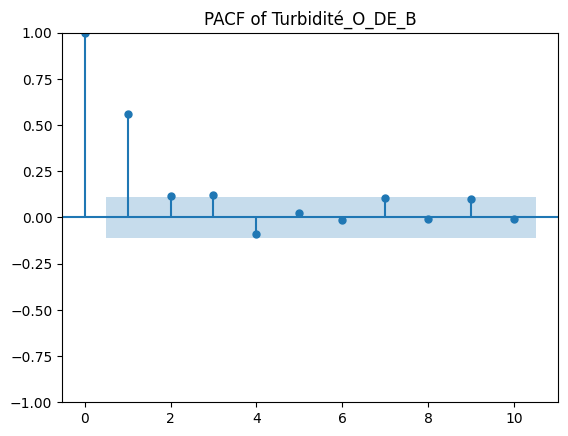

In [14]:
# ACF and PACF for each BC variable
for col in DE_data.columns[1:]:
    plot_acf(DE_data[col].dropna(), lags=10)
    plt.title(f'ACF of {col}')
    plt.show()

    plot_pacf(DE_data[col].dropna(), lags=10)
    plt.title(f'PACF of {col}')
    plt.show()

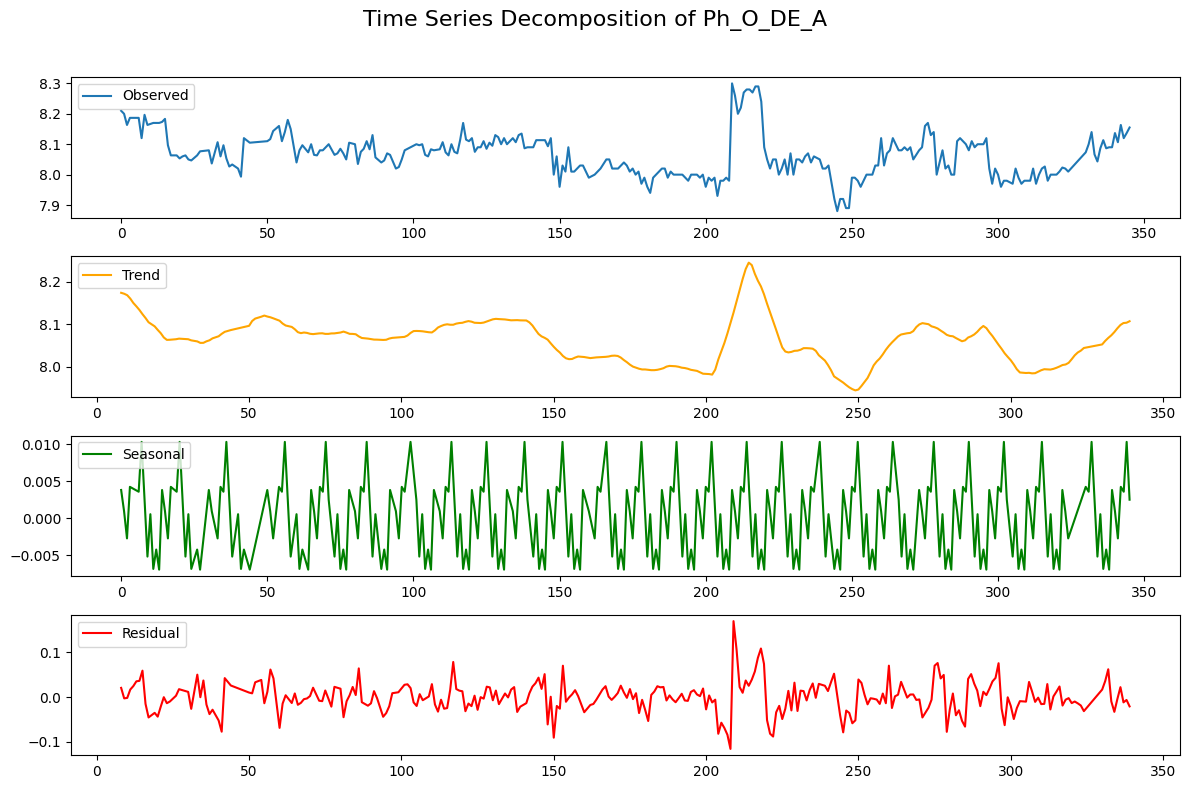

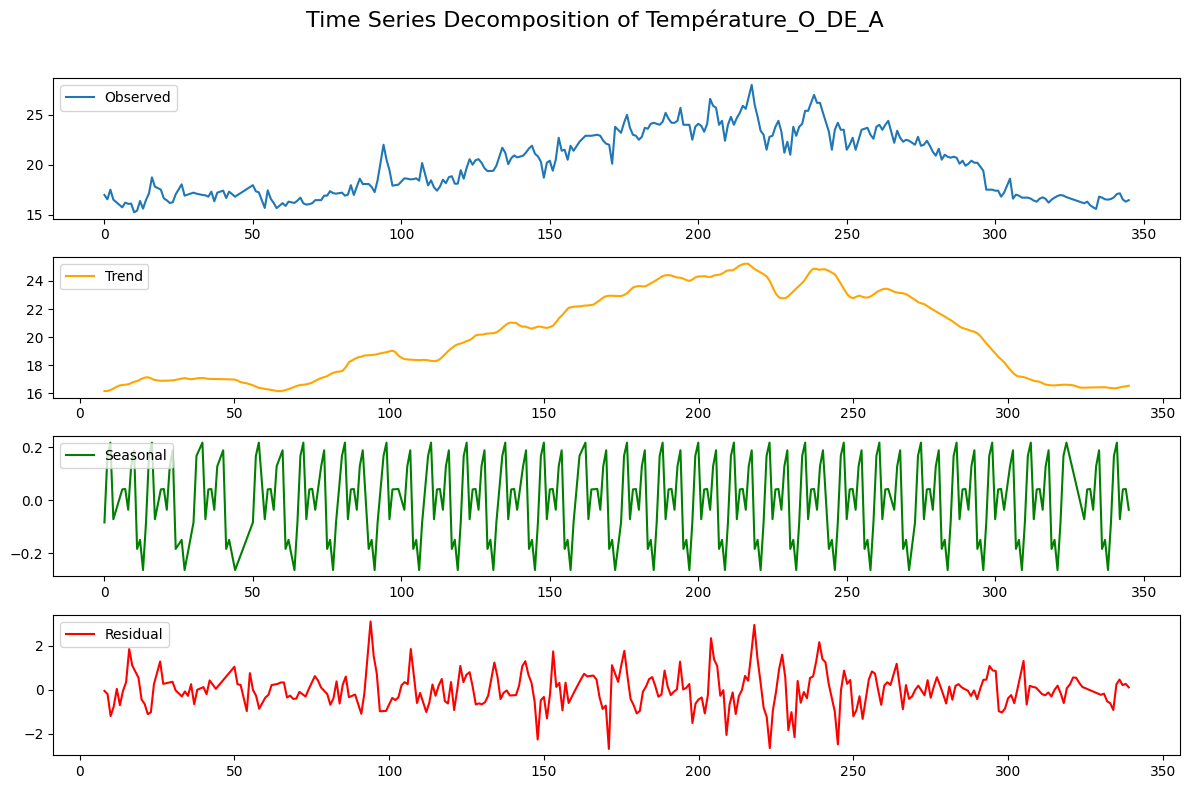

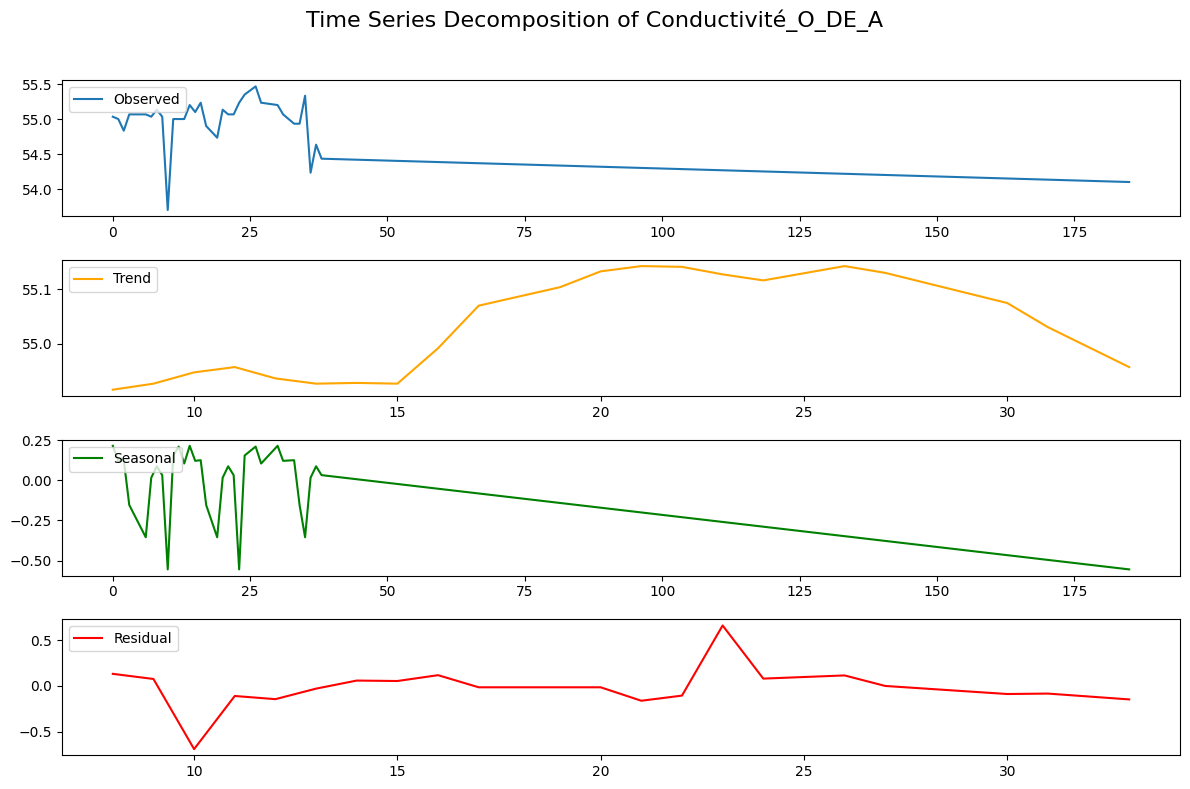

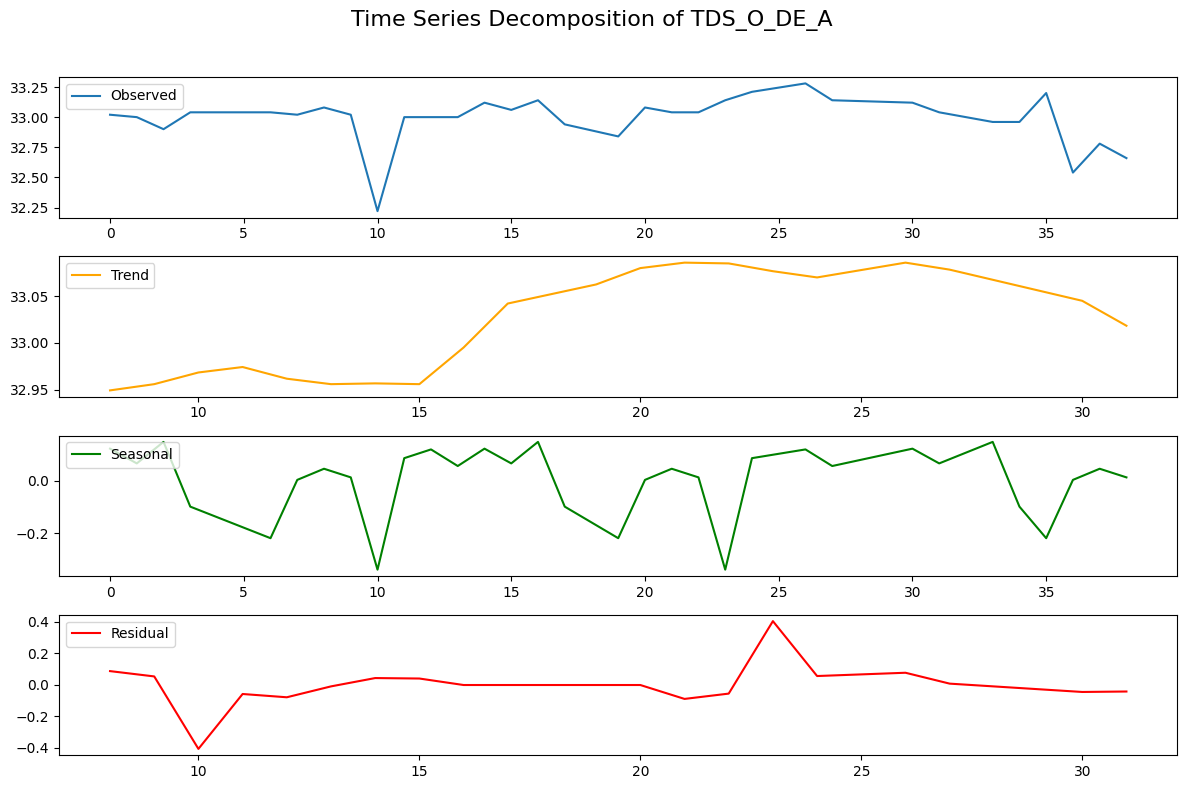

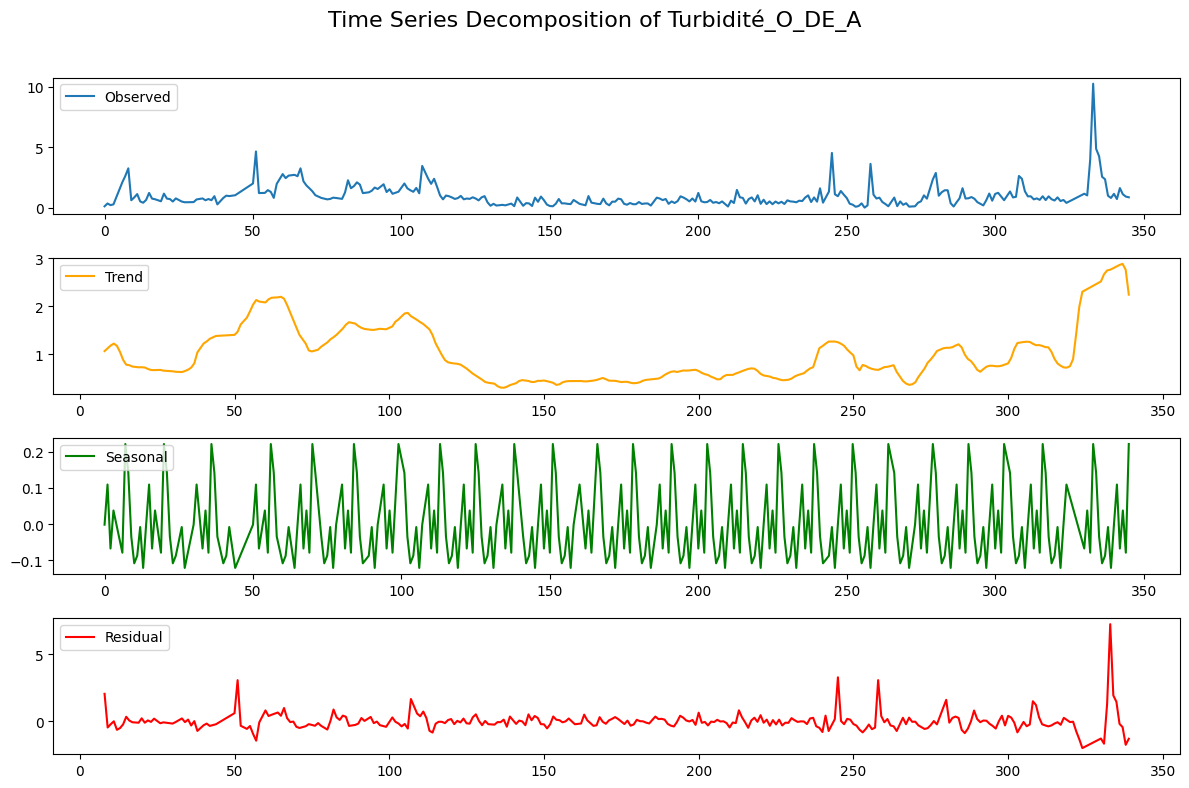

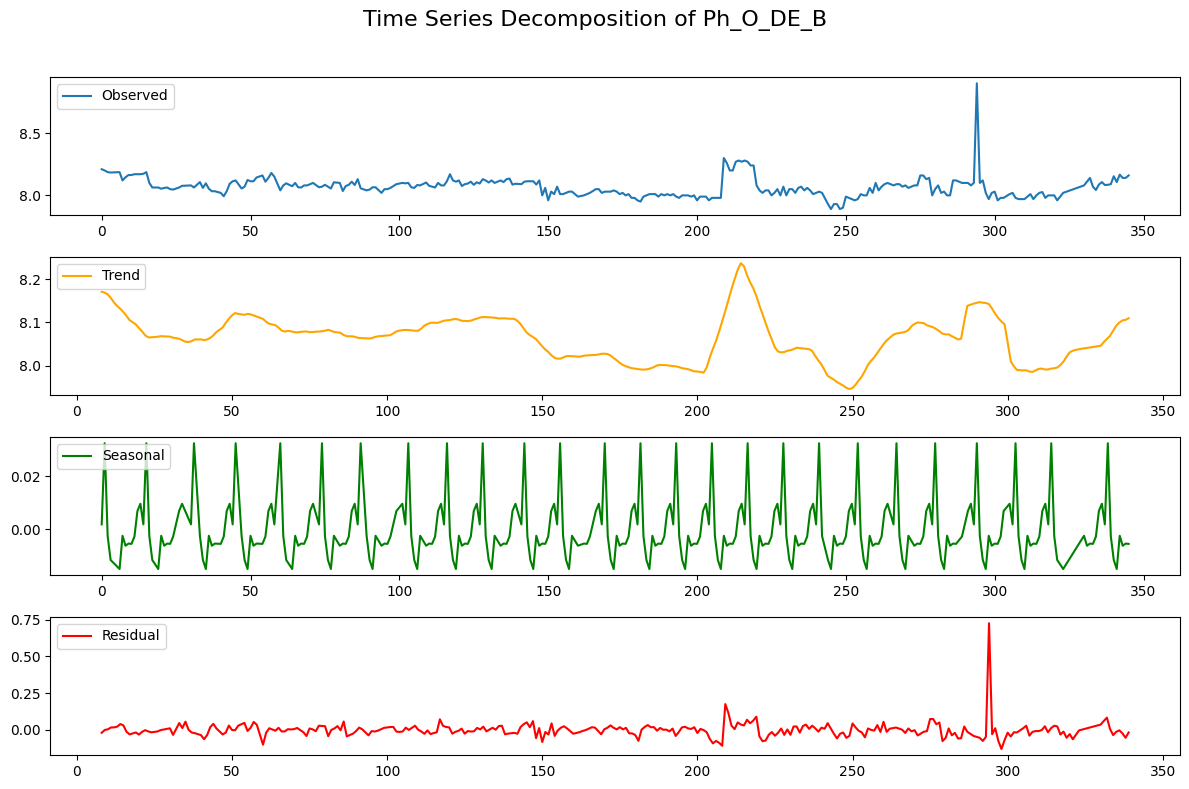

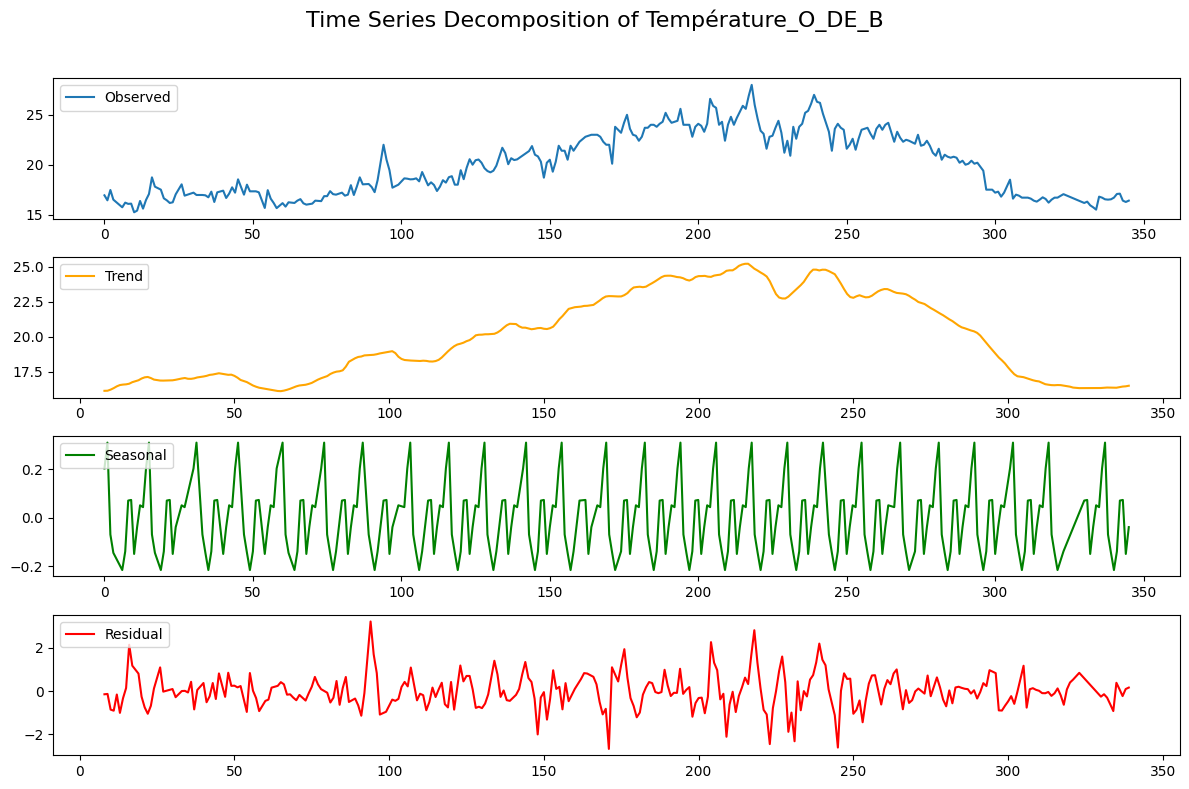

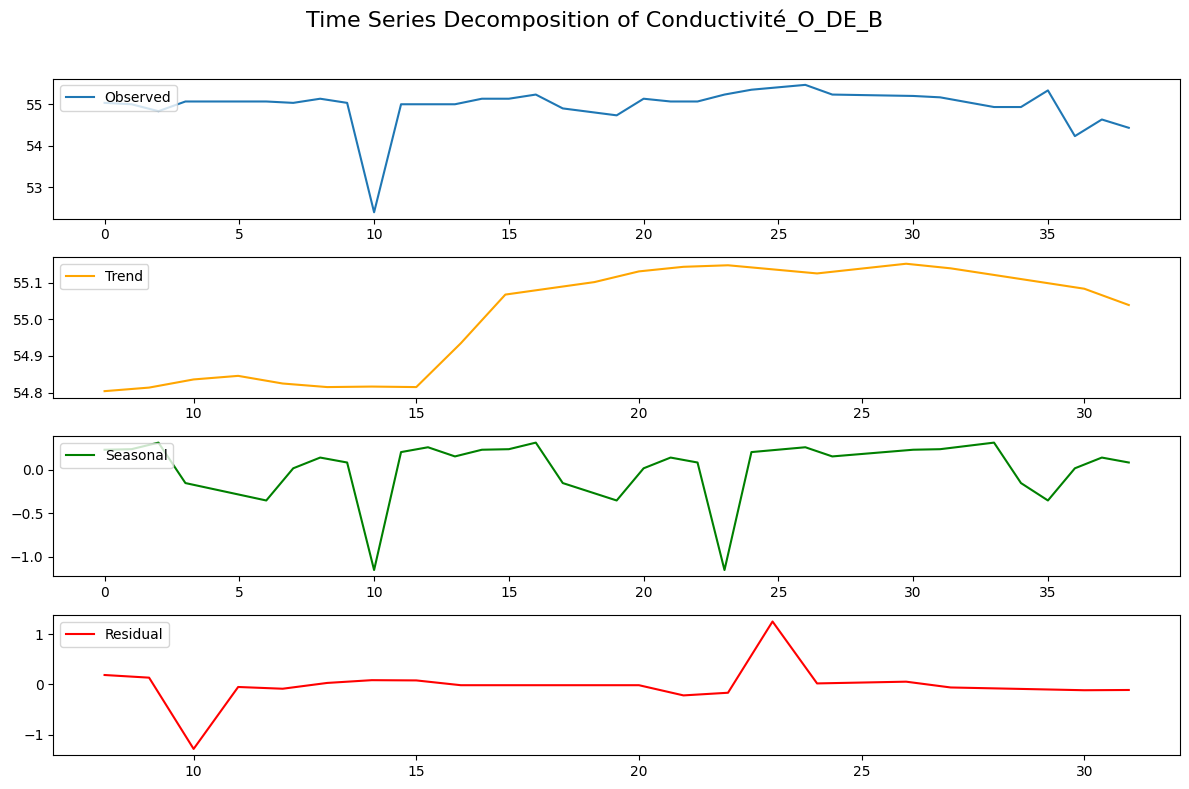

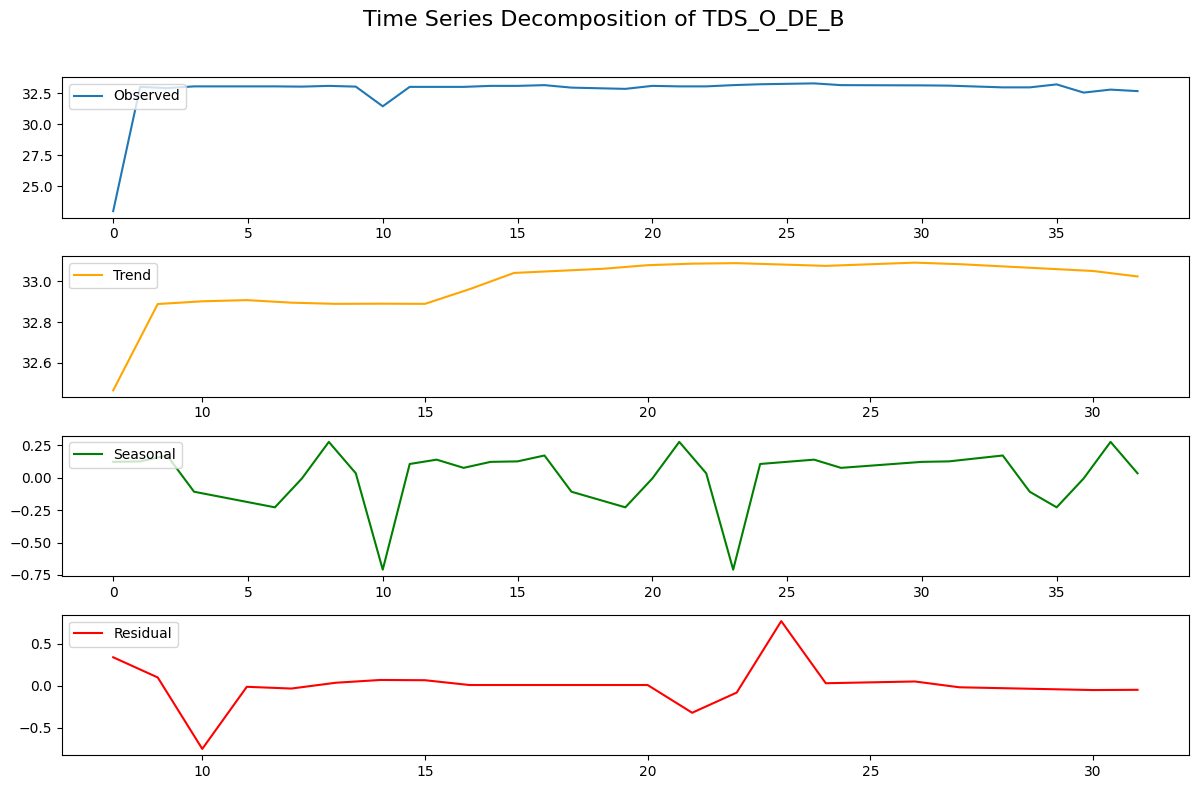

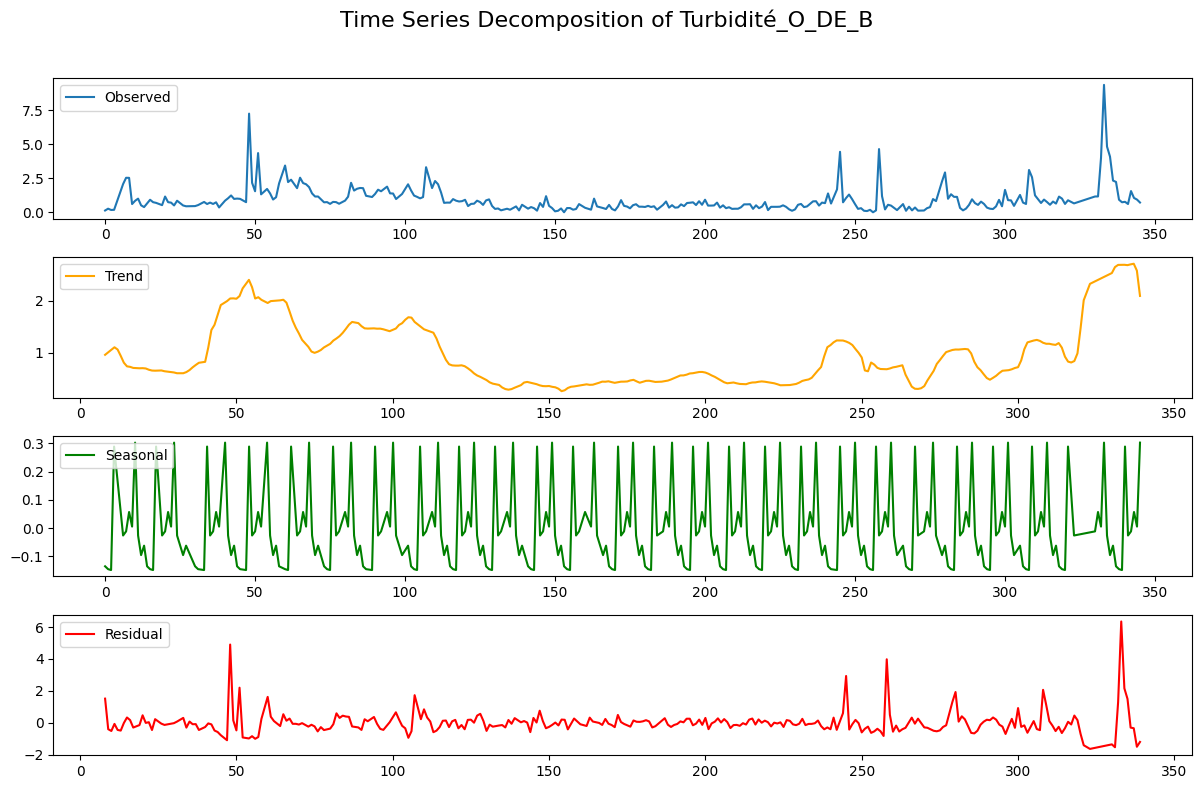

In [15]:
# time series decomposition for each DE variable

for col in DE_data.columns[1:]:
    decomp = seasonal_decompose(DE_data[col].dropna(), model='additive', period=12)
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Time Series Decomposition of {col}', fontsize=16)
    plt.subplot(411)
    plt.plot(decomp.observed, label='Observed')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(decomp.trend, label='Trend', color='orange')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(decomp.seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(decomp.resid, label='Residual', color='red')
    plt.legend(loc='upper left')
    plt.tight_layout(rect=[0, 0, 1, 0.96])